# Example-10: Multi-pass iterative Hankel SVD decomposition

In [1]:
# Import

import numpy
import torch
import yaml

import sys
sys.path.append('..')

from harmonica.util import mod
from harmonica.window import Window
from harmonica.data import Data
from harmonica.frequency import Frequency
from harmonica.filter import Filter
from harmonica.decomposition import Decomposition

import matplotlib.pyplot as plt

torch.set_printoptions(precision=12, sci_mode=True)
print(torch.cuda.is_available())

True


In [2]:
# Set data type and device

dtype = torch.float64
device = torch.device('cpu')

In [3]:
# Generate test signal with three components and noise

size = 2**10
time  = torch.linspace(0.0, size - 1.0, size, dtype=dtype, device=device)

signal  = torch.zeros_like(time)
signal += 0.50*torch.sin(2.0*numpy.pi*0.12*time)
signal += 0.10*torch.sin(2.0*numpy.pi*0.24*time)
signal += 0.01*torch.sin(2.0*numpy.pi*0.36*time)
signal += 0.001*torch.randn_like(signal)

# Set window & data

win = Window(size, 'cosine_window', 1.0, dtype=dtype, device=device)
tbt = Data.from_data(win, signal.reshape(1, -1))

# Estimate signal rank and noise
# Note, for a (quasiperiodic) signal with zero mean, number of components is half the estimated rank

flt = Filter(tbt)
rank, noise = flt.estimate_noise(limit=32)
print(rank)
print(noise)

tensor([6])
tensor([1.073042867328e-03], dtype=torch.float64)


In [4]:
# Perform decompostion

s1, s2, s3, *_ = Decomposition.decomposition_hsvd(3, signal, np=2, ni=4)

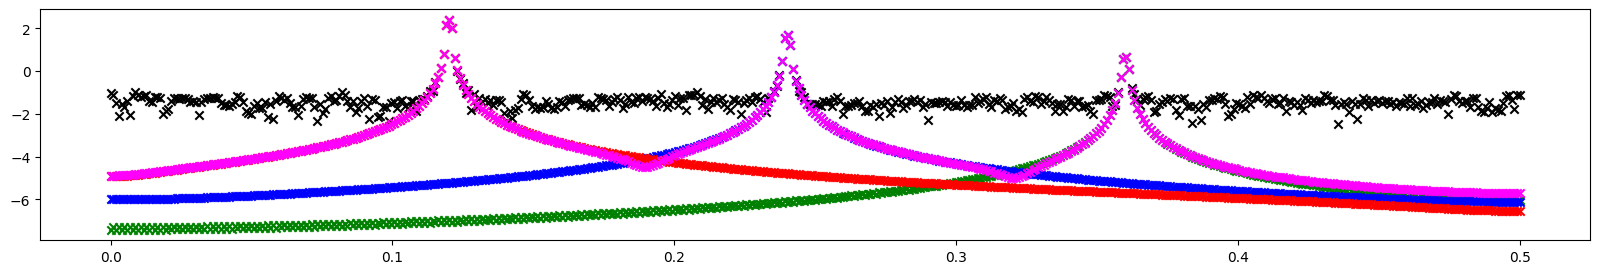

In [5]:
# Plot spectrum

grid = torch.fft.rfftfreq(size).cpu().numpy()

plt.figure(figsize=(20, 3))
plt.scatter(grid, torch.fft.rfft(signal*win.window).abs().log10().cpu().numpy(), color='black', marker='x')
plt.scatter(grid, torch.fft.rfft(s3*win.window).abs().log10().cpu().numpy(), color='green', marker='x')
plt.scatter(grid, torch.fft.rfft(s2*win.window).abs().log10().cpu().numpy(), color='blue', marker='x')
plt.scatter(grid, torch.fft.rfft(s1*win.window).abs().log10().cpu().numpy(), color='red', marker='x')
plt.scatter(grid, torch.fft.rfft((s1 + s2 + s3)*win.window).abs().log10().cpu().numpy(), color='magenta', marker='x')

plt.show()

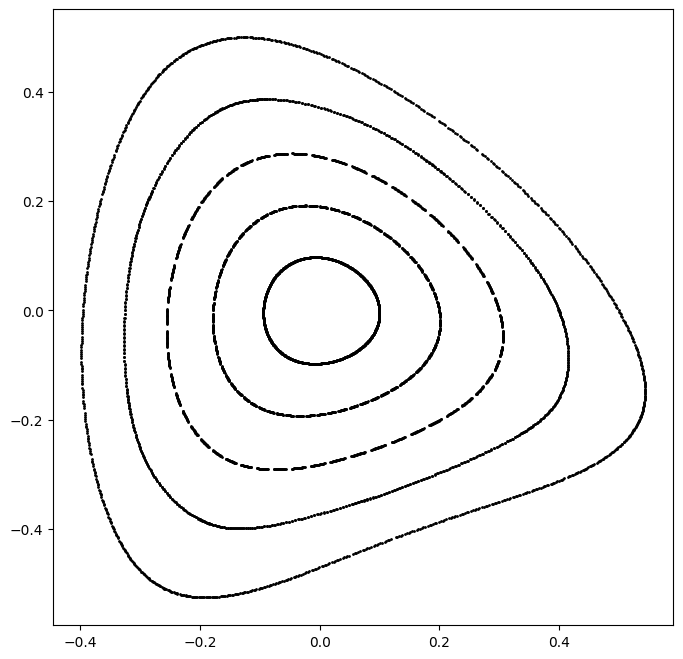

In [6]:
# Define nonlinear map

amplitude = torch.tensor(1.0, dtype=dtype, device=device)

nux = torch.tensor(2.0*numpy.pi*0.38, dtype=dtype, device=device)
nuy = torch.tensor(2.0*numpy.pi*0.41, dtype=dtype, device=device)

cx, sx = nux.cos(), nux.sin()
cy, sy = nuy.cos(), nuy.sin()


@torch.func.vmap
def henon(state:torch.tensor) -> torch.tensor:
    local = torch.clone(state)
    local[0] = cx*state[0] + sx*(amplitude*(state[0]**2 -state[2]**2) + state[1])
    local[1] = cx*(amplitude*(state[0]**2 - state[2]**2) + state[1]) - sx*state[0]
    local[2] = cy*state[2] + sy*(state[3] - 2.0*amplitude*state[0]*state[2])
    local[3] = cy*(state[3] - 2.0*amplitude*state[0]*state[2]) + sy*state[2]
    return local

# Generate test trajectories

state = torch.tensor(
    [
        [0.10, 0.0, 0.0, 0.0],
        [0.20, 0.0, 0.0, 0.0],
        [0.30, 0.0, 0.0, 0.0],
        [0.40, 0.0, 0.0, 0.0],
        [0.50, 0.0, 0.0, 0.0]
    ], 
    dtype=dtype, device=device)

qx, px = [], []
qx.append(state[:, 0])
px.append(state[:, 1])

count = 2**10 - 1
for _ in range(count):
    state = henon(state)
    qx.append(state[:, 0])
    px.append(state[:, 1])

qx = torch.stack(qx).cpu().numpy()
px = torch.stack(px).cpu().numpy()

plt.figure(figsize=(8, 8))
for qxi, pxi in zip(qx, px):
    plt.scatter(qxi, pxi, color='black', marker='o', s=1)
plt.show()

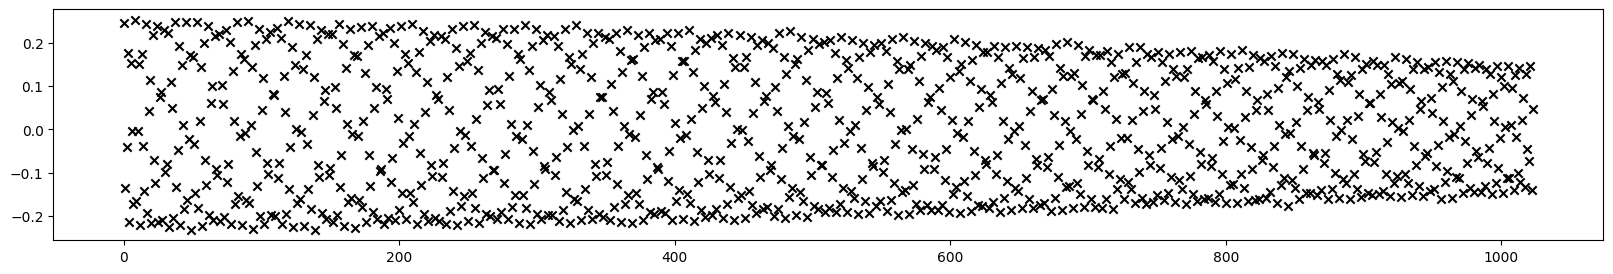

In [7]:
# Generate initial distribution

qx = 0.25 + 0.01*torch.randn(2**20, dtype=dtype, device=device)
px = 0.00 + 0.01*torch.randn(2**20, dtype=dtype, device=device)
qy = torch.zeros_like(qx)
py = torch.zeros_like(px)

# Track distribution

orbit = []

state = torch.stack([qx, px, qy, py]).T
orbit.append(state[:, 0].mean())

count = 2**10 - 1
for _ in range(count):
    state = henon(state)
    orbit.append(state[:, 0].mean())
    
orbit = torch.stack(orbit)

# Add noise & remove mean

orbit += 0.005*torch.randn_like(orbit)
orbit -= orbit.mean()

# Plot centroid

plt.figure(figsize=(20, 3))
plt.scatter(range(count + 1), orbit.cpu().numpy(), color='black', marker='x')
plt.show()

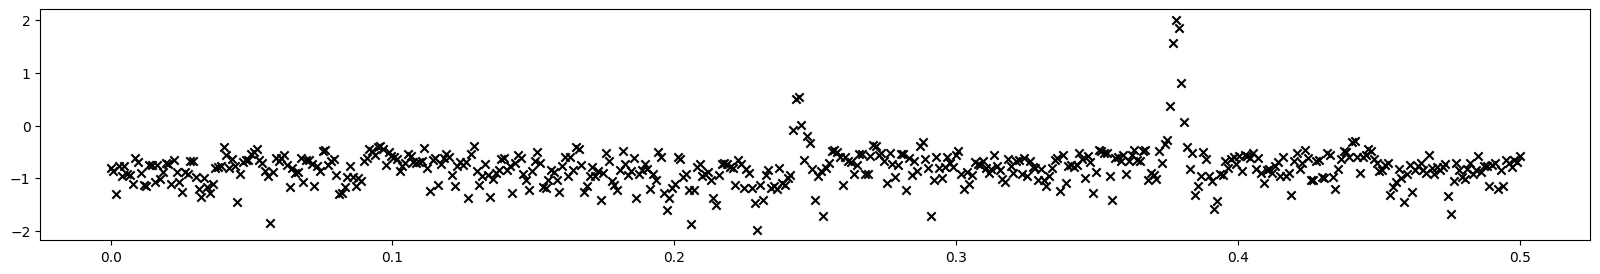

In [8]:
# Plot centroid spectrum

plt.figure(figsize=(20, 3))
plt.scatter(torch.fft.rfftfreq(size).cpu().numpy(), torch.fft.rfft(orbit*win.window).abs().log10().cpu().numpy(), color='black', marker='x')

plt.show()

In [9]:
# Set window & data

win = Window(size, 'cosine_window', 1.0, dtype=dtype, device=device)
tbt = Data.from_data(win, orbit.reshape(1, -1))
tbt.add_noise(torch.tensor([0.001], dtype=dtype, device=device))

# Estimate signal rank and noise

flt = Filter(tbt)
rank, noise = flt.estimate_noise(limit=64)
print(rank)
print(noise)

tensor([4])
tensor([5.139350577897e-03], dtype=torch.float64)


In [10]:
# Perform decompostion
# Note, here only two components are used
# In fact, the third component for this example should be combined with the first one
# In general, components with close frequencies should be merged

s1, s2, *_ = Decomposition.decomposition_hsvd(2, orbit, np=2, ni=8)

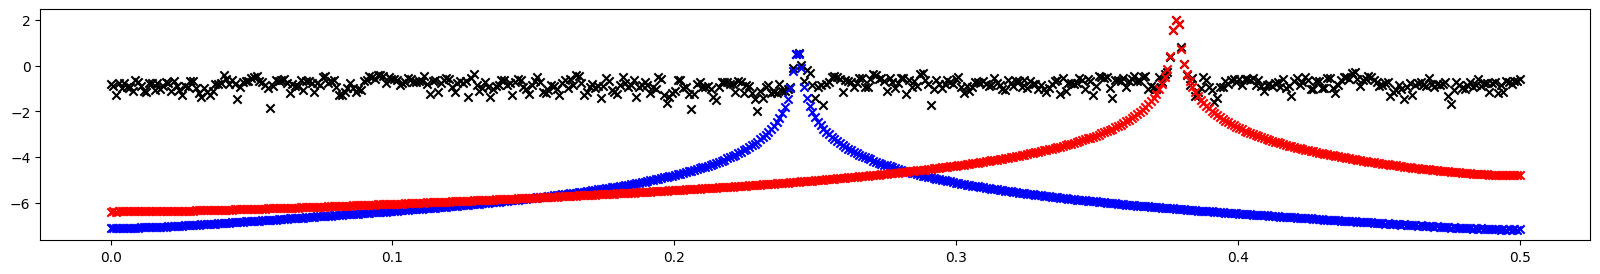

In [11]:
# Plot spectrum

grid = torch.fft.rfftfreq(len(orbit)).cpu().numpy()

plt.figure(figsize=(20, 3))
plt.scatter(grid, torch.fft.rfft(orbit*win.window).abs().log10().cpu().numpy(), color='black', marker='x')
plt.scatter(grid, torch.fft.rfft(s2*win.window).abs().log10().cpu().numpy(), color='blue', marker='x')
plt.scatter(grid, torch.fft.rfft(s1*win.window).abs().log10().cpu().numpy(), color='red', marker='x')

plt.show()

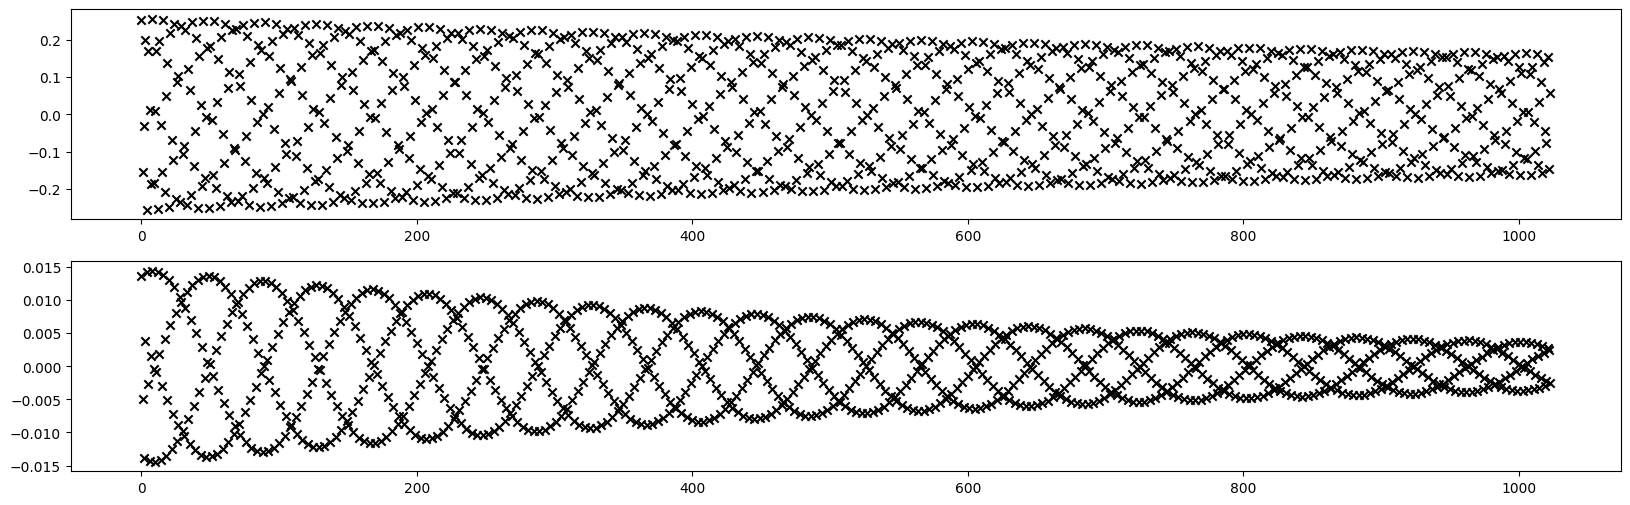

In [12]:
# Plot components

plt.figure(figsize=(20, 2*3))

ax = plt.subplot(211)
ax.scatter(range(len(s1)), s1.cpu().numpy(), color='black', marker='x')

ax = plt.subplot(212)
ax.scatter(range(len(s2)), s2.cpu().numpy(), color='black', marker='x')

plt.show()